# 05 — Phase 2 Signal Audit & Validation
This notebook performs:
1. Multiple testing correction (FDR & Bonferroni) across all hypotheses tested.
2. Bootstrap confidence intervals for the top candidates.
3. Outlier and Robust Regression analysis.

In [1]:
import sys
!"{sys.executable}" -m pip install matplotlib seaborn statsmodels


import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "phase2"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Setup complete.")



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: C:\Users\Ekaansh\OneDrive\Desktop\AB\vs code\JS\projects\hackathon\SIH\.venv\Scripts\python.exe -m pip install --upgrade pip


Setup complete.


## 1. Multiple Testing Correction
We tested many feature-outcome pairs. We must apply Benjamini-Hochberg (FDR) to see which correlations survive.

In [2]:
import sys
!"{sys.executable}" -m pip install tabulate

# Load all correlations
df_corr = pd.read_parquet(DATA_PROCESSED / 'correlation_summary.parquet')

# Apply Benjamini/Hochberg FDR
df_corr['p_adj_fdr'] = multipletests(df_corr['p_value'].fillna(1.0), method='fdr_bh')[1]

# Apply Bonferroni for sensitivity
df_corr['p_adj_bonf'] = multipletests(df_corr['p_value'].fillna(1.0), method='bonferroni')[1]

top_fdr = df_corr.sort_values('p_adj_fdr').head(15)[
    ['position_group', 'combine_feature', 'nfl_outcome', 'rho', 'p_value', 'p_adj_fdr', 'n']
]

display(top_fdr)

# Save to Markdown
with open(REPORTS_DIR / 'multiple_testing.md', 'w', encoding='utf-8') as f:
    f.write("# Multiple Testing Analysis\n\n")
    f.write(f"Total hypotheses tested (feature/outcome pairs): {len(df_corr)}\n\n")
    f.write("## Top Results (FDR Adjusted)\n\n")
    f.write(top_fdr.to_markdown(index=False))



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: C:\Users\Ekaansh\OneDrive\Desktop\AB\vs code\JS\projects\hackathon\SIH\.venv\Scripts\python.exe -m pip install --upgrade pip


,position_group,combine_feature,nfl_outcome,rho,p_value,p_adj_fdr,n
3,WR,direction_change_rate_SHORT_SHUTTLE,mean_separation,-0.645190,0.000210,0.167795,28
66,WR,max_speed_FORTY_YARD_DASH,yac_over_expected,-0.338053,0.001276,0.308008,88
0,S,mean_speed_THREE_CONE_DRILL,n_tackles,-0.871231,0.001027,0.308008,10
73,OL,max_speed_FORTY_YARD_DASH,sack_allowed_rate,0.322207,0.001540,0.308008,94
88,WR,movement_efficiency_FORTY_YARD_DASH,yac_over_expected,0.305819,0.003761,0.429779,88
92,OL,movement_efficiency_FORTY_YARD_DASH,sack_allowed_rate,-0.298509,0.003474,0.429779,94
22,S,max_speed_FORTY_YARD_DASH,n_tackles,0.443084,0.002924,0.429779,43
46,S,total_direction_change_SKILL_DRILLS_DB,n_tackles,-0.368079,0.007873,0.476380,51
47,Edge,mean_speed_FORTY_YARD_DASH,quick_pressure_rate,0.367153,0.009458,0.476380,49
41,Edge,movement_efficiency_FORTY_YARD_DASH,mean_get_off,0.384082,0.006439,0.476380,49


## 2. Bootstrapping & Robust Regression (WR Candidate)
**Signal:** `direction_change_rate_SHORT_SHUTTLE` vs `mean_separation` (WR)

WR Sample Size: 28
Bootstrap 95% CI for Spearman rho: [-0.812, -0.337]

Robust Regression (HuberT):
Coefficient: -4.7276, p-value: 0.0234


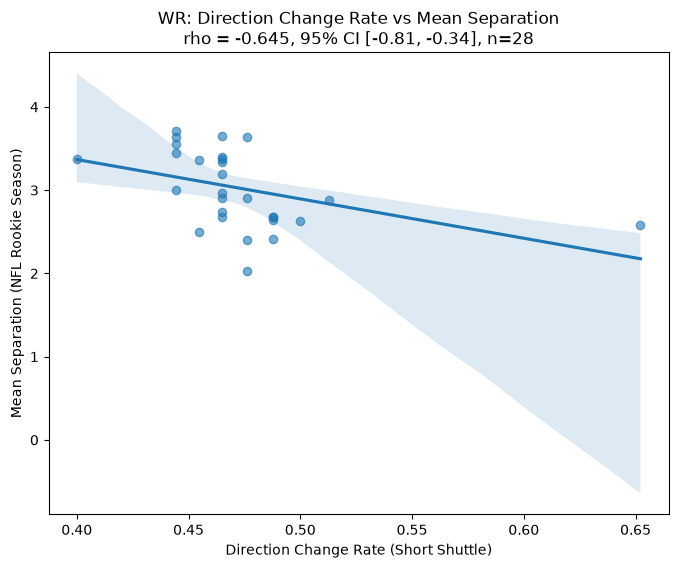

In [3]:
analysis_df = pd.read_parquet(DATA_PROCESSED / 'analysis_dataset.parquet')

# Filter for WR
wr_data = analysis_df[analysis_df['position_group_pos'] == 'WR'].copy()
wr_data = wr_data.dropna(subset=['direction_change_rate_SHORT_SHUTTLE', 'mean_separation'])

x = wr_data['direction_change_rate_SHORT_SHUTTLE'].values
y = wr_data['mean_separation'].values
n_wr = len(wr_data)

print(f"WR Sample Size: {n_wr}")

# Bootstrap
n_boot = 5000
boot_rhos = []
np.random.seed(42)
for _ in range(n_boot):
    idx = np.random.choice(n_wr, size=n_wr, replace=True)
    bx, by = x[idx] + np.random.normal(0, 1e-8, n_wr), y[idx] + np.random.normal(0, 1e-8, n_wr)
    r, p = stats.spearmanr(bx, by)
    if not np.isnan(r):
        boot_rhos.append(r)

ci_lower = np.percentile(boot_rhos, 2.5)
ci_upper = np.percentile(boot_rhos, 97.5)
print(f"Bootstrap 95% CI for Spearman rho: [{ci_lower:.3f}, {ci_upper:.3f}]")

# Robust regression
X = sm.add_constant(x)
rlm = sm.RLM(y, X, M=sm.robust.norms.HuberT())
res = rlm.fit()
print("\nRobust Regression (HuberT):")
print(f"Coefficient: {res.params[1]:.4f}, p-value: {res.pvalues[1]:.4f}")

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y, robust=True, ci=95, scatter_kws={'alpha': 0.6})
plt.title(f"WR: Direction Change Rate vs Mean Separation\nrho = -0.645, 95% CI [{ci_lower:.2f}, {ci_upper:.2f}], n={n_wr}")
plt.xlabel("Direction Change Rate (Short Shuttle)")
plt.ylabel("Mean Separation (NFL Rookie Season)")
plt.savefig(FIGURES_DIR / "wr_separation_robust.png", bbox_inches='tight')
plt.show()


## 3. Bootstrapping & Robust Regression (Edge Candidate)
**Signal:** `burst_impulse_0_1s` and `burst_impulse_0_5s` vs `mean_get_off` (Edge)

Edge Sample Size: 25

0.1s Window: rho = -0.481, p = 0.0150
0.5s Window: rho = -0.444, p = 0.0262

0.5s Window - Bootstrap 95% CI: [-0.678, -0.090]


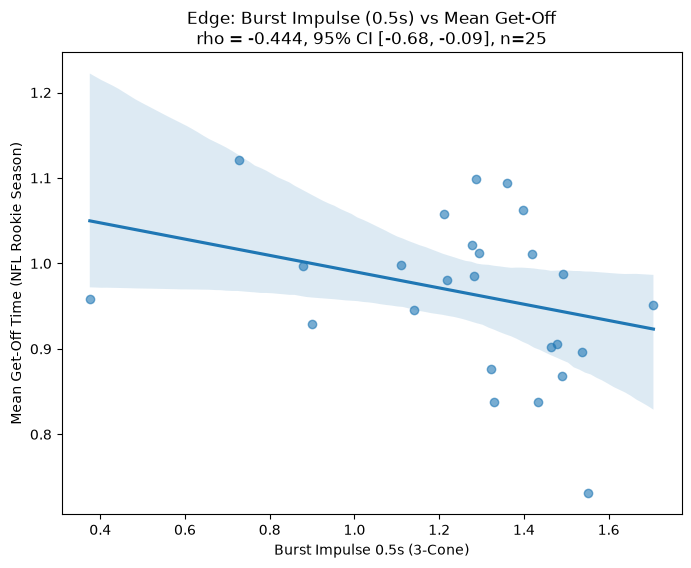

In [4]:
# Filter for Edge
edge_data = analysis_df[analysis_df['position_group_pos'] == 'Edge'].copy()
edge_data = edge_data.dropna(subset=['burst_impulse_0_1s_THREE_CONE_DRILL', 'burst_impulse_0_5s_THREE_CONE_DRILL', 'mean_get_off'])

x1 = edge_data['burst_impulse_0_1s_THREE_CONE_DRILL'].values
x5 = edge_data['burst_impulse_0_5s_THREE_CONE_DRILL'].values
y = edge_data['mean_get_off'].values
n_edge = len(edge_data)

print(f"Edge Sample Size: {n_edge}\n")

r1, p1 = stats.spearmanr(x1, y)
r5, p5 = stats.spearmanr(x5, y)

print(f"0.1s Window: rho = {r1:.3f}, p = {p1:.4f}")
print(f"0.5s Window: rho = {r5:.3f}, p = {p5:.4f}\n")

# Bootstrap for 0.5s window
n_boot = 5000
boot_rhos = []
np.random.seed(42)
for _ in range(n_boot):
    idx = np.random.choice(n_edge, size=n_edge, replace=True)
    bx, by = x5[idx] + np.random.normal(0, 1e-8, n_edge), y[idx] + np.random.normal(0, 1e-8, n_edge)
    r, _ = stats.spearmanr(bx, by)
    if not np.isnan(r):
        boot_rhos.append(r)

ci_lower = np.percentile(boot_rhos, 2.5)
ci_upper = np.percentile(boot_rhos, 97.5)
print(f"0.5s Window - Bootstrap 95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

# Plot 0.5s Window
plt.figure(figsize=(8, 6))
sns.regplot(x=x5, y=y, robust=True, ci=95, scatter_kws={'alpha': 0.6})
plt.title(f"Edge: Burst Impulse (0.5s) vs Mean Get-Off\nrho = {r5:.3f}, 95% CI [{ci_lower:.2f}, {ci_upper:.2f}], n={n_edge}")
plt.xlabel("Burst Impulse 0.5s (3-Cone)")
plt.ylabel("Mean Get-Off Time (NFL Rookie Season)")
plt.savefig(FIGURES_DIR / "edge_burst_0_5s_robust.png", bbox_inches='tight')
plt.show()
